In [1]:
from dataAnalysis.DataAnalysis import DataAnalysis
import pandas as pd
from torch.nn.functional import normalize
from sklearn.ensemble import RandomForestClassifier
from EnsembleFramework import Framework
from sklearn.metrics import roc_curve
from numpy import sqrt, argmax
from joblib import dump, load
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import shap
import os
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import RUSBoostClassifier

In [2]:
from pylab import *
from math import sin
rc('text', usetex = False)
la = matplotlib.font_manager.FontManager()
lu = matplotlib.font_manager.FontProperties(family = 'Arial')

In [3]:
data = pd.read_csv(r"extdata/sbcdata.csv", header=0)
data_analysis = DataAnalysis(data)

/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Label'] = self.data['Diagnosis']
/home/dwalke/git/sbc_app/dataAnalysis/data/Filter.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [4]:
sorted_train_data = data_analysis.get_training_data().sort_values(by="Id").reset_index(drop = True)
train_df = sorted_train_data.loc[:sorted_train_data.shape[0]*.8,:]
val_df = sorted_train_data.loc[sorted_train_data.shape[0]*.8:,:]
test_df = data_analysis.get_testing_data()
gw_df = data_analysis.get_gw_testing_data()

In [5]:
import numpy as np
import torch
from dataAnalysis.Constants import FEATURES, LABEL_COLUMN_NAME

def convert_cat_feature(df):
    df = df.copy()
    df["SexCategory"] = (df["Sex"] == "W").astype(int)
    return df
    
def get_graph(df):
    edge_index = []
    df = convert_cat_feature(df)
    df = df.sort_values(by=["Id", "Time"]).reset_index(drop=True)
    
    ## group df by ids
    for identifier, group in df.groupby("Id"):
        offset = group.index[0]
        triu_matrix = np.triu((group.index.values + np.identity(1))[0])
        triu_exp_matrix = np.expand_dims(triu_matrix, axis=-1)
    
        idx_shape = group.index.shape[0]
        idx_matrix = np.ones((idx_shape, idx_shape)) * np.arange(idx_shape) + 1 + offset
        idx_matrix = np.transpose(idx_matrix)
        idx_exp_matrix = np.expand_dims(idx_matrix, axis=-1)
    
        unprocess_edges = np.concatenate((idx_exp_matrix, triu_exp_matrix), axis=-1)
        reshaped_unprocess_edges = np.reshape(unprocess_edges, (-1, 2))
        mask = (reshaped_unprocess_edges[:, 0] * reshaped_unprocess_edges[:, 1]) != 0
        edge_index.append((reshaped_unprocess_edges[mask] - 1).astype(np.int64))
    edge_index_torch = torch.from_numpy(np.concatenate(edge_index)).type(torch.long).transpose(0,1)
    features_torch = torch.from_numpy(df[FEATURES].values).type(torch.float)
    labels_torch = torch.from_numpy((df.sort_values(by=["Id", "Time"])[LABEL_COLUMN_NAME] == "Sepsis").values).type(torch.long)
    return features_torch, edge_index_torch, labels_torch

In [6]:
X_train_comp, edge_index_train_comp, y_train_comp = get_graph(sorted_train_data)
X_train, edge_index_train, y_train = get_graph(train_df)
X_val, edge_index_val, y_val = get_graph(val_df)
X_test, edge_index_test, y_test = get_graph(test_df)
X_gw, edge_index_gw, y_gw = get_graph(gw_df)

In [7]:
rev_edge_index_train_comp = torch.zeros_like(edge_index_train_comp)
rev_edge_index_train_comp[0,:] = edge_index_train_comp[1,:]
rev_edge_index_train_comp[1,:] = edge_index_train_comp[0,:]

rev_edge_index_train = torch.zeros_like(edge_index_train)
rev_edge_index_train[0,:] = edge_index_train[1,:]
rev_edge_index_train[1,:] = edge_index_train[0,:]

rev_edge_index_val = torch.zeros_like(edge_index_val)
rev_edge_index_val[0,:] = edge_index_val[1,:]
rev_edge_index_val[1,:] = edge_index_val[0,:]

rev_edge_index_test = torch.zeros_like(edge_index_test)
rev_edge_index_test[0,:] = edge_index_test[1,:]
rev_edge_index_test[1,:] = edge_index_test[0,:]

rev_edge_index_gw = torch.zeros_like(edge_index_gw)
rev_edge_index_gw[0,:] = edge_index_gw[1,:]
rev_edge_index_gw[1,:] = edge_index_gw[0,:]

In [8]:
from torch_geometric.utils import to_undirected

undir_edge_index_comp = to_undirected(edge_index_train_comp)
undir_edge_index_train = to_undirected(edge_index_train)
undir_edge_index_val = to_undirected(edge_index_val)
undir_edge_index_test = to_undirected(edge_index_test)
undir_edge_index_gw = to_undirected(edge_index_gw)

/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [9]:
def get_features(framework, X, edge_index):
    return framework.get_features(X, edge_index, torch.ones(X.shape[0]).type(torch.bool))

In [10]:
dir_sets = [("train_comp", X_train_comp, edge_index_train_comp, y_train_comp), ("train", X_train, edge_index_train, y_train), ("val", X_val, edge_index_val, y_val), ("test", X_test, edge_index_test, y_test),
       ("gw", X_gw, edge_index_gw, y_gw)]
dir_sets_dict = {dir_set[0]: (dir_set[1:]) for dir_set in dir_sets}
rev_dir_sets = [("train_comp", X_train_comp, rev_edge_index_train_comp, y_train_comp), ("train", X_train, rev_edge_index_train, y_train), ("val", X_val, rev_edge_index_val, y_val), ("test", X_test, rev_edge_index_test, y_test),
       ("gw", X_gw, rev_edge_index_gw, y_gw)]
rev_dir_sets_dict = {rev_dir_set[0]: (rev_dir_set[1:]) for rev_dir_set in rev_dir_sets}
undir_sets = [("train_comp", X_train_comp, undir_edge_index_comp, y_train_comp), ("train", X_train, undir_edge_index_train, y_train), ("val", X_val, undir_edge_index_val, y_val), ("test", X_test, undir_edge_index_test, y_test),
       ("gw", X_gw, undir_edge_index_gw, y_gw)]
undir_sets_dict = {undir_set[0]: (undir_set[1:]) for undir_set in undir_sets}

In [11]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
def test_auroc_and_auprc(framework, clf, X, edge_index,y):
    features = torch.cat(get_features(framework, X, edge_index), dim = 1)
    pred_proba = clf.predict_proba(features.cpu())[:,1]
    auroc = roc_auc_score(y, pred_proba)

    precision, recall, thresholds = precision_recall_curve(y, pred_proba)
    auprc = auc(recall, precision)
    return auroc, auprc


In [12]:
def eval_rev(framework, clf):
    eval_dict = dict()
    for name in rev_dir_sets_dict:
        X, edge_index,y = rev_dir_sets_dict[name]
        auroc, auprc = test_auroc_and_auprc(framework, clf, X, edge_index,y)
        eval_dict[name] = dict()
        eval_dict[name]["AUROC"] = np.round(auroc, 4)
        eval_dict[name]["AUPRC"] = np.round(auprc, 4)
    return eval_dict
        
def eval_dir(framework, clf):
    eval_dict = dict()
    for name in dir_sets_dict:
        X, edge_index,y = dir_sets_dict[name]
        auroc, auprc = test_auroc_and_auprc(framework,clf, X, edge_index,y)
        eval_dict[name] = dict()
        eval_dict[name]["AUROC"] = np.round(auroc, 4)
        eval_dict[name]["AUPRC"] = np.round(auprc, 4)
    return eval_dict

In [13]:
edge_type_sets = {
    "dir": dir_sets_dict,
    "rev_dir": rev_dir_sets_dict,
    # "undir": undir_sets_dict,
}

In [14]:
def user_function(kwargs):
    return kwargs["updated_features"] - kwargs["mean_neighbors"]

hops = [0, 1]

In [35]:
def fit_prospective_model(propsective_model, sc = None):
    framework = Framework(user_functions=[user_function, user_function], 
                             hops_list=[0,1],
                             clfs=[None, None],
                             gpu_idx=0,
                             handle_nan=0.0,
                            attention_configs=[ None, None])
    X_train, edge_index_train, y_train = edge_type_sets["dir"]["train_comp"]
    features_train = torch.cat(get_features(framework, X_train, edge_index_train), dim = 1).cpu().numpy()
    if sc is not None:
        sc.fit(features_train)
        features_train = sc.transform(features_train)
    propsective_model.fit(features_train, y_train)
    return propsective_model, framework

def get_prospective_pred_proba(propsective_model, framework, sc = None):
    pred_proba_dict = dict()
    for name in edge_type_sets["dir"]:
        X, edge_index,y = edge_type_sets["dir"][name]
        features = torch.cat(get_features(framework, X, edge_index), dim = 1).cpu().numpy()
        if sc is not None:
            features = sc.transform(features)
        pred_proba = propsective_model.predict_proba(features)[:,1]
        pred_proba_dict[name] = pred_proba
    return pred_proba_dict
    

def evaluate_prospective_model(propsective_model, framework, sc = None):
    eval_dict = dict()
    pred_proba_dict = get_prospective_pred_proba(propsective_model, framework, sc)
    for name in edge_type_sets["dir"]:
        X, edge_index,y = edge_type_sets["dir"][name]
        pred_proba = pred_proba_dict[name]
        auroc = roc_auc_score(y, pred_proba)
    
        precision, recall, thresholds = precision_recall_curve(y, pred_proba)
        auprc = auc(recall, precision)
        eval_dict[name] = dict()
        eval_dict[name]["auroc"] = np.round(auroc, 3)
        eval_dict[name]["auprc"] = np.round(auprc, 3)
    return eval_dict

def fit_retrospective_model(retrosective_model, sc = None):
    framework = Framework(user_functions=[user_function, user_function], 
                             hops_list=[0,1],
                             clfs=[None, None],
                             gpu_idx=0,
                             handle_nan=0.0,
                            attention_configs=[ None, None])
    X_train, edge_index_train, y_train = edge_type_sets["rev_dir"]["train_comp"]
    features_train = torch.cat(get_features(framework, X_train, edge_index_train), dim = 1).cpu().numpy()
    if sc is not None:
        sc.fit(features_train)
        features_train = sc.transform(features_train)
    retrosective_model.fit(features_train, y_train)
    return retrosective_model, framework

def get_retrospective_pred_proba(retrosective_model, framework, sc = None):
    pred_proba_dict = dict()
    for name in edge_type_sets["rev_dir"]:
        X, edge_index,y = edge_type_sets["rev_dir"][name]
        features = torch.cat(get_features(framework, X, edge_index), dim = 1).cpu().numpy()
        if sc is not None:
            features = sc.transform(features)
        pred_proba = retrosective_model.predict_proba(features)[:,1]
        pred_proba_dict[name] = pred_proba
    return pred_proba_dict

def evaluate_retrospective_model(retrosective_model, framework, sc = None):
    eval_dict = dict()
    pred_proba_dict = get_retrospective_pred_proba(retrosective_model, framework, sc)
    for name in edge_type_sets["rev_dir"]:
        X, edge_index,y = edge_type_sets["rev_dir"][name]
        pred_proba = pred_proba_dict[name]
        auroc = roc_auc_score(y, pred_proba)
    
        precision, recall, thresholds = precision_recall_curve(y, pred_proba)
        auprc = auc(recall, precision)
        eval_dict[name] = dict()
        eval_dict[name]["auroc"] = np.round(auroc, 3)
        eval_dict[name]["auprc"] = np.round(auprc, 3)
    return eval_dict

In [36]:
def get_best_prospective_threshold(model, framework, sc = None):
    X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
    features_test = torch.cat(get_features(framework, X_test, edge_index_test), dim = 1).cpu().numpy()
    if sc is not None:
        features_test = sc.transform(features_test)
    pred_proba = model.predict_proba(features_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
    gmeans = sqrt(tpr * (1-fpr))
    ix = argmax(gmeans)
    return round(thresholds[ix], 4) 

def get_best_restrospective_threshold(model, framework, sc = None):
    X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
    features_test = torch.cat(get_features(framework, X_test, edge_index_test), dim = 1).cpu().numpy()
    if sc is not None:
        features_test = sc.transform(features_test)
    pred_proba = model.predict_proba(features_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
    gmeans = sqrt(tpr * (1-fpr))
    ix = argmax(gmeans)
    return round(thresholds[ix], 4) 

In [37]:
from sklearn.metrics import confusion_matrix
def get_propsective_sensistivity_at_specifity(model, framework, sc = None, desired_specificity = .8):
    sensitivity_dict = dict()
    for name in edge_type_sets["dir"]:
        X, edge_index,y = edge_type_sets["dir"][name]
        features = torch.cat(get_features(framework, X, edge_index), dim = 1).cpu().numpy()
        if sc is not None:
            features = sc.transform(features)
        y_pred_proba = model.predict_proba(features)[:, 1]
        fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
        
        desired_specificity = 0.8
        desired_fpr = 1 - desired_specificity
        
        for i, fp_rate in enumerate(fpr):
            if fp_rate >= desired_fpr:
                threshold = thresholds[i]
                break
        
        y_pred = (y_pred_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        sensitivity_dict[name] = {
            "sensitivity": sensitivity,
        }
    return sensitivity_dict
    
def get_retrospective_sensistivity_at_specifity(model, framework, sc = None, desired_specificity = .8):
    sensitivity_dict = dict()
    for name in edge_type_sets["rev_dir"]:
        X, edge_index,y = edge_type_sets["rev_dir"][name]
        features = torch.cat(get_features(framework, X, edge_index), dim = 1).cpu().numpy()
        if sc is not None:
            features = sc.transform(features)
        y_pred_proba = model.predict_proba(features)[:, 1]
        fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
        
        desired_specificity = 0.8
        desired_fpr = 1 - desired_specificity
        
        for i, fp_rate in enumerate(fpr):
            if fp_rate >= desired_fpr:
                threshold = thresholds[i]
                break
        
        y_pred = (y_pred_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        sensitivity_dict[name] = {
            "sensitivity": sensitivity,
        }
    return sensitivity_dict

In [38]:
def print_and_export_shap_overview(shap_vals, title:str, overall_plt_title:str):

    samples_shap_vals = shap_vals[:, :7]
    time_shap_vals = shap_vals[:, 7:]
    plt.rcParams.update({'font.size': 12})
    fig =  plt.figure(figsize=(30, 15))
    gs = fig.add_gridspec(2, 2)
    FEATURES[1] = "Sex"
    
    ax = fig.add_subplot(gs[0, 0])
    plt.sca(ax)
    shap.summary_plot(samples_shap_vals, plot_type="bar", class_inds='original',show=False,  feature_names = FEATURES)
    ax.set_xlabel("Mean |shap values|")
    ax.grid()
    is_decision_tree = "_dt" in title
    if is_decision_tree:
        ax.tick_params(axis='x', labelsize=8)
    ax.set_title(f"Feature importance of original features")
    
    ax = fig.add_subplot(gs[0, 1])
    plt.sca(ax)
    shap.summary_plot(time_shap_vals, plot_type="bar",  class_inds='original',show=False,  feature_names = FEATURES)
    ax.set_xlabel("Mean |shap values|")
    ax.grid()
    ax.set_title(f"Feature importance of time features")
    
    ax = fig.add_subplot(gs[1, :])
    plt.sca(ax)
    shap.summary_plot(np.sum((np.abs(samples_shap_vals), np.abs(time_shap_vals)), axis = 0), plot_type="bar", show=False,  class_inds='original', feature_names = FEATURES)
    ax.set_xlabel("Mean |shap values|")
    ax.set_title(f"Overall feature importance")
    ax.grid()
    plt.tight_layout()
    plt.show()
    fig.savefig(f"{title}.png", dpi = 300, bbox_inches='tight',format="png")

    plt.rcParams.update({'font.size': 22})
    fig =  plt.figure(figsize=(30, 15))
    gs = fig.add_gridspec(2, 2)
    FEATURES[1] = "Sex"
    ax = fig.add_subplot(gs[:, :])
    plt.sca(ax)
    shap.summary_plot(np.sum((np.abs(samples_shap_vals), np.abs(time_shap_vals)), axis = 0), plot_type="bar", show=False,  class_inds='original', feature_names = FEATURES)
    ax.set_xlabel("Mean |shap values|")
    ax.set_title(overall_plt_title)
    ax.grid()
    plt.tight_layout()
    plt.show()
    fig.savefig(f"overall_{title}.png", dpi = 300, bbox_inches='tight',format="png")

## Pred proba exporter

In [39]:
prospective_pred_probas = pd.DataFrame()
retrospective_pred_probas = pd.DataFrame()

prospective_pred_probas["y"] = y_test
retrospective_pred_probas["y"] = y_test

## Random forest

### Prospective model

In [40]:
prospective_model_rf, framework_dir = fit_prospective_model(RandomForestClassifier(**{'class_weight': {0: 0.0022, 1: 1}, 'max_leaf_nodes': 96, 'min_samples_leaf': 0.0003683813065159676, 'min_samples_split': 0.0065797321149668915, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}))
eval_dict = evaluate_prospective_model(prospective_model_rf, framework_dir)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_prospective_threshold(prospective_model_rf, framework_dir)
print(f"Best threshold is {best_threshold}")
sensitivity_scores = get_propsective_sensistivity_at_specifity(prospective_model_rf, framework_dir)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_scores).to_html()))
if not os.path.exists('prospective_random_forest.joblib'):
    dump(prospective_model_rf, 'prospective_random_forest.joblib')


,train_comp,train,val,test,gw
auroc,0.934,0.934,0.935,0.889,0.840
auprc,0.034,0.033,0.042,0.023,0.009


Best threshold is 0.3564
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.91481,0.915763,0.908257,0.808163,0.716518


In [41]:
pred_proba_dict = get_prospective_pred_proba(prospective_model_rf, framework_dir)
prospective_pred_probas[prospective_model_rf.__class__.__name__] = pred_proba_dict["test"]

/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/dwalke/.local/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


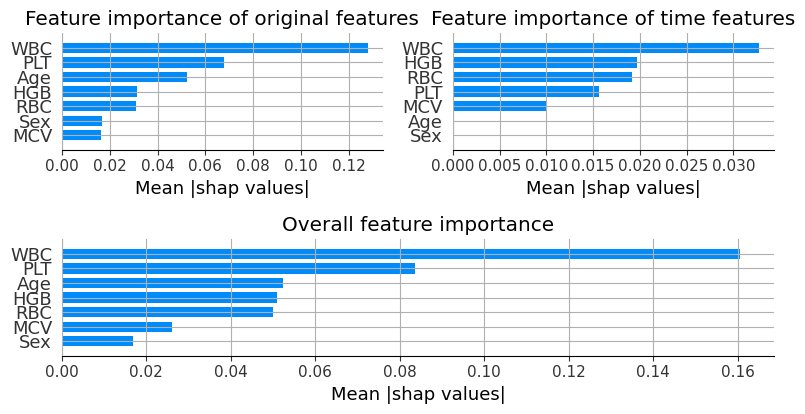

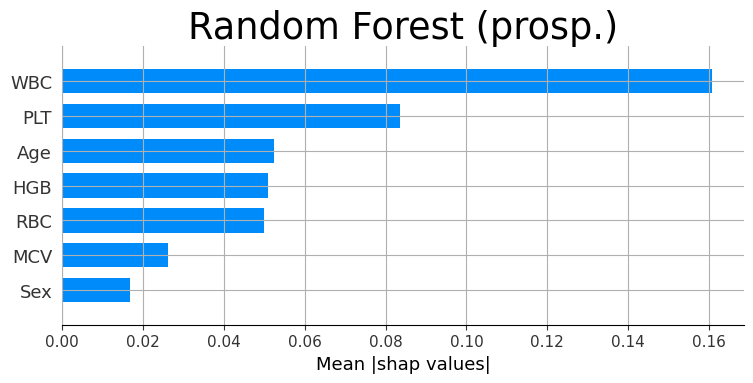

In [20]:
explainer = shap.TreeExplainer(prospective_model_rf)
X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
features_test = torch.cat(get_features(framework_dir, X_test, edge_index_test), dim = 1).cpu().numpy()
prospective_rf_test_shap_vals = None
if os.path.exists('prospective_rf_test_shap_vals.npy'):
    prospective_rf_test_shap_vals = np.load('prospective_rf_test_shap_vals.npy')
else:
    prospective_rf_test_shap_vals = explainer.shap_values(features_test)[-1]
    np.save('prospective_rf_test_shap_vals.npy', prospective_rf_test_shap_vals)
print_and_export_shap_overview(prospective_rf_test_shap_vals, "prospective_rf", "Random Forest (prosp.)")

### Retrospective model

In [42]:
retrospective_model_rf, framework_rev = fit_retrospective_model(RandomForestClassifier(**{'class_weight': {0: 0.0022, 1: 1}, 'max_leaf_nodes': 76, 'min_samples_leaf': 0.0001679711412637778, 'min_samples_split': 0.005791441918035724, 'n_estimators': 400, 'n_jobs': -1, 'random_state': 42}))
eval_dict = evaluate_retrospective_model(retrospective_model_rf, framework_rev)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_restrospective_threshold(retrospective_model_rf, framework_rev)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_retrospective_sensistivity_at_specifity(retrospective_model_rf, framework_rev)
print("Sensitivity for 80% specifity")
print(sensitivity_vals)
if not os.path.exists('retrospective_random_forest.joblib'):
    dump(retrospective_model_rf, 'retrospective_random_forest.joblib')

,train_comp,train,val,test,gw
auroc,0.964,0.964,0.964,0.942,0.953
auprc,0.060,0.060,0.063,0.044,0.029


Best threshold is 0.3917
Sensitivity for 80% specifity
{'train_comp': {'sensitivity': 0.973132372214941}, 'train': {'sensitivity': 0.9733110925771477}, 'val': {'sensitivity': 0.9724770642201835}, 'test': {'sensitivity': 0.926530612244898}, 'gw': {'sensitivity': 0.9441964285714286}}


In [43]:
pred_proba_dict = get_retrospective_pred_proba(retrospective_model_rf, framework_rev)
retrospective_pred_probas[retrospective_model_rf.__class__.__name__] = pred_proba_dict["test"]

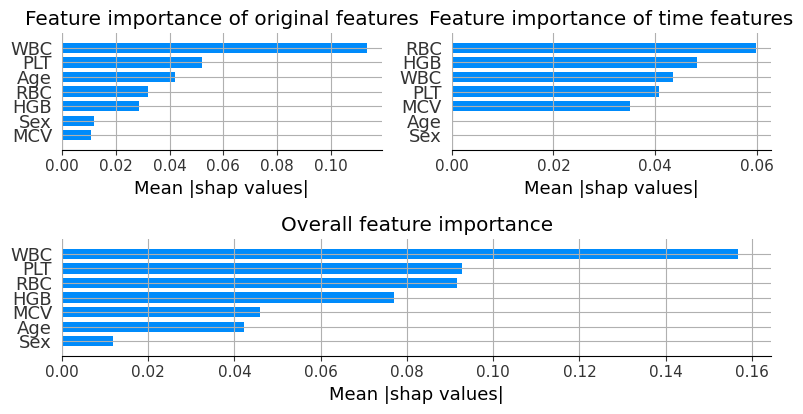

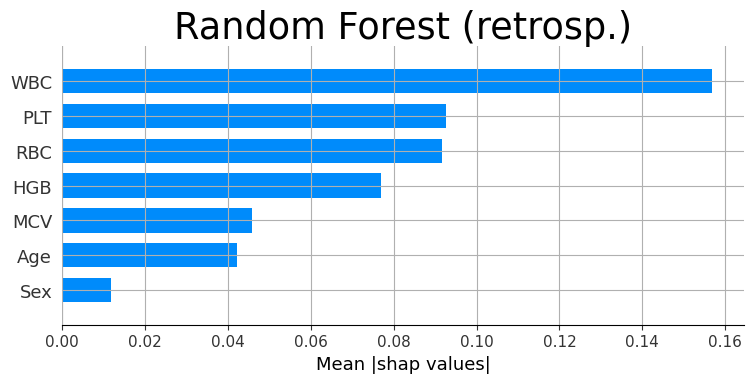

In [22]:
explainer = shap.TreeExplainer(retrospective_model_rf)
X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
features_test = torch.cat(get_features(framework_rev, X_test, edge_index_test), dim = 1).cpu().numpy()
retrospective_rf_test_shap_vals = None
if os.path.exists('retrospective_rf_test_shap_vals.npy'):
    retrospective_rf_test_shap_vals = np.load('retrospective_rf_test_shap_vals.npy')
else:
    retrospective_rf_test_shap_vals = explainer.shap_values(features_test)[-1]
    np.save('retrospective_rf_test_shap_vals.npy', retrospective_rf_test_shap_vals)
print_and_export_shap_overview(retrospective_rf_test_shap_vals, "retrospective_rf", "Random Forest (retrosp.)")

## Logistic Regression

### Prospective model

In [44]:
sc = StandardScaler()
prospective_model_lr, framework_dir = fit_prospective_model(LogisticRegression(**{'C': 1358.1636018605177, 'class_weight': {0: 0.0022147379349917173, 1: 1}, 'max_iter': 550, 'random_state': 42, 'solver': 'liblinear'}), sc)
eval_dict = evaluate_prospective_model(prospective_model_lr, framework_dir, sc)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_prospective_threshold(prospective_model_lr, framework_dir, sc)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_propsective_sensistivity_at_specifity(prospective_model_lr, framework_dir, sc)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('prospective_lr.joblib'):
    dump(prospective_model_lr, 'prospective_lr.joblib')
    dump(sc, 'prospective_sc.joblib')

,train_comp,train,val,test,gw
auroc,0.840,0.841,0.838,0.841,0.757
auprc,0.013,0.013,0.014,0.009,0.004


Best threshold is 0.4028
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.719528,0.722269,0.70948,0.72449,0.591518


In [45]:
pred_proba_dict = get_prospective_pred_proba(prospective_model_lr, framework_dir, sc)
prospective_pred_probas[prospective_model_lr.__class__.__name__] = pred_proba_dict["test"]

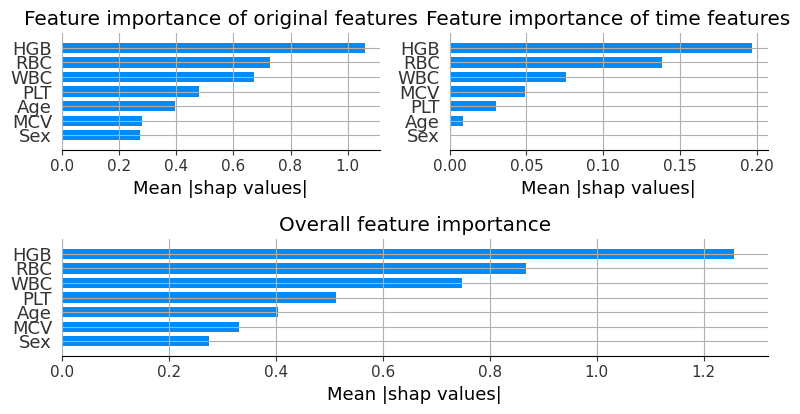

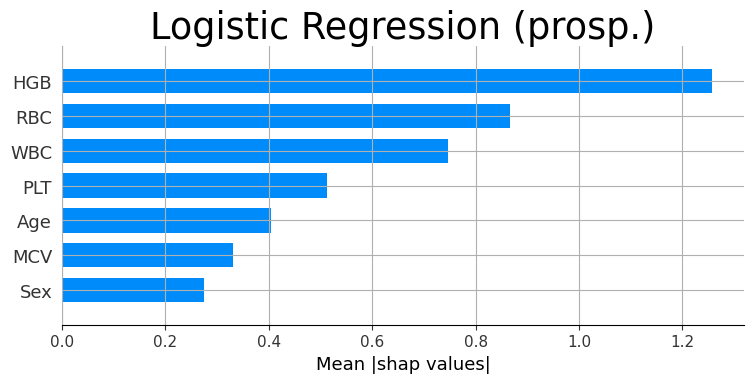

In [24]:
X_background, edge_index_background, _ = edge_type_sets["dir"]["train_comp"]
features_background = torch.cat(get_features(framework_dir, X_background, edge_index_background), dim = 1).cpu().numpy()
features_background = sc.transform(features_background)
explainer = shap.LinearExplainer(prospective_model_lr, features_background)
X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
features_test = torch.cat(get_features(framework_dir, X_test, edge_index_test), dim = 1).cpu().numpy()
features_test = sc.transform(features_test)
prospective_lr_test_shap_vals = None
if os.path.exists('prospective_lr_test_shap_vals.npy'):
    prospective_lr_test_shap_vals = np.load('prospective_lr_test_shap_vals.npy')
else:
    prospective_lr_test_shap_vals = explainer.shap_values(features_test)
    np.save('prospective_lr_test_shap_vals.npy', prospective_lr_test_shap_vals)
print_and_export_shap_overview(prospective_lr_test_shap_vals, "prospective_lr", "Logistic Regression (prosp.)")

### Retrospective model

In [52]:
sc = StandardScaler()
retrospective_model_lr, framework_rev = fit_retrospective_model(LogisticRegression(**{'C': 9860.73511529326, 'class_weight': {0: 0.0022147379349917173, 1: 1}, 'l1_ratio': 0.001162164137936239, 'max_iter': 750, 'random_state': 42, 'solver': 'liblinear'}), sc)
eval_dict = evaluate_retrospective_model(retrospective_model_lr, framework_rev, sc)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_restrospective_threshold(retrospective_model_lr, framework_rev, sc)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_retrospective_sensistivity_at_specifity(retrospective_model_lr, framework_rev, sc)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('retrospective_logistic_regression.joblib'):
    dump(retrospective_model_lr, 'retrospective_logistic_regression.joblib')
    dump(retrospective_model_lr, 'retrospective_sc.joblib')

/home/dwalke/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,train_comp,train,val,test,gw
auroc,0.849,0.850,0.849,0.851,0.783
auprc,0.015,0.014,0.016,0.011,0.005


Best threshold is 0.4011
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.741809,0.743953,0.737003,0.730612,0.631696


In [53]:
pred_proba_dict = get_retrospective_pred_proba(retrospective_model_lr, framework_rev, sc)
retrospective_pred_probas[retrospective_model_lr.__class__.__name__] = pred_proba_dict["test"]

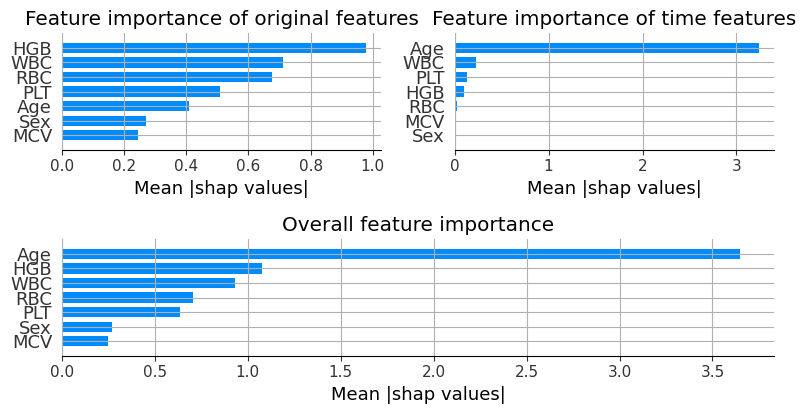

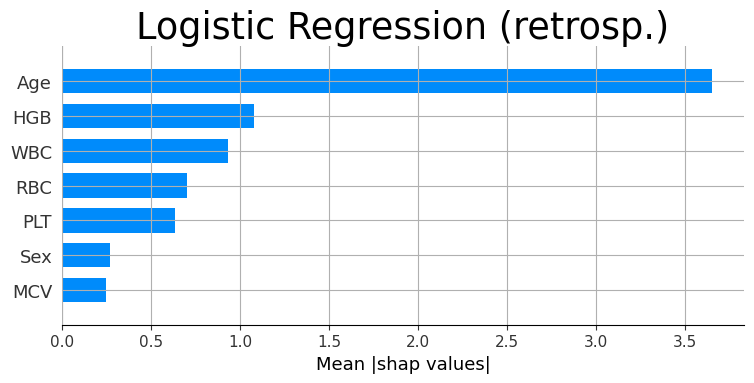

In [26]:
X_background, edge_index_background, _ = edge_type_sets["rev_dir"]["train_comp"]
features_background = torch.cat(get_features(framework_rev, X_background, edge_index_background), dim = 1).cpu().numpy()
features_background = sc.transform(features_background)
explainer = shap.LinearExplainer(retrospective_model_lr, features_background)
X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
features_test = torch.cat(get_features(framework_rev, X_test, edge_index_test), dim = 1).cpu().numpy()
features_test = sc.transform(features_test)
retrospective_lr_test_shap_vals = None
if os.path.exists('retrospective_lr_test_shap_vals.npy'):
    retrospective_lr_test_shap_vals = np.load('retrospective_lr_test_shap_vals.npy')
else:
    retrospective_lr_test_shap_vals = explainer.shap_values(features_test)
    np.save('retrospective_lr_test_shap_vals.npy', retrospective_lr_test_shap_vals)
print_and_export_shap_overview(retrospective_lr_test_shap_vals, "retrosepctive_lr", "Logistic Regression (retrosp.)")

## XGBoost

### Prospective model

In [47]:
prospective_model_xgb, framework_dir = fit_prospective_model(XGBClassifier(**{'alpha': 9.538284629683702, 'booster': 'gbtree', 'colsample_bytree': 0.9080724508103653, 'gamma': 0.8284271722786946, 'lambda': 0.00906801548010611, 'learning_rate': 0.15996292193138167, 'max_depth': 3, 'min_child_weight': 3.3449149107880025, 'n_estimators': 150, 'n_jobs': -1, 'objective': 'binary:logistic', 'random_state': 42, 'scale_pos_weight': 1, 'subsample': 0.8923516991674396}))
eval_dict = evaluate_prospective_model(prospective_model_xgb, framework_dir)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_prospective_threshold(prospective_model_xgb, framework_dir)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_propsective_sensistivity_at_specifity(prospective_model_xgb, framework_dir)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('prospective_xgb.joblib'):
    dump(prospective_model_xgb, 'prospective_xgb.joblib')

,train_comp,train,val,test,gw
auroc,0.915,0.915,0.914,0.888,0.839
auprc,0.048,0.048,0.049,0.028,0.011


Best threshold is 0.0017999999690800905
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.860419,0.864887,0.844037,0.806122,0.705357


In [48]:
pred_proba_dict = get_prospective_pred_proba(prospective_model_xgb, framework_dir)
prospective_pred_probas[prospective_model_xgb.__class__.__name__] = pred_proba_dict["test"]

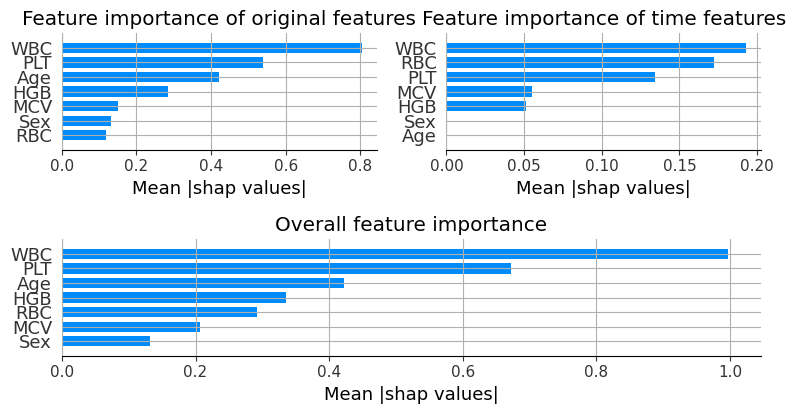

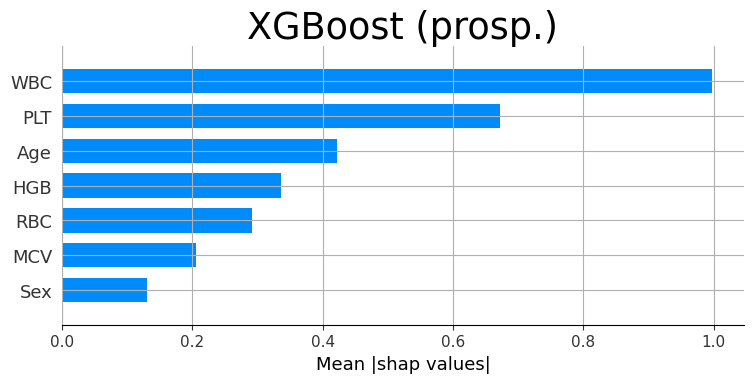

In [28]:
explainer = shap.TreeExplainer(prospective_model_xgb)
X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
features_test = torch.cat(get_features(framework_dir, X_test, edge_index_test), dim = 1).cpu().numpy()
prospective_xgb_test_shap_vals = None
if os.path.exists('prospective_xgb_test_shap_vals.npy'):
    prospective_xgb_test_shap_vals = np.load('prospective_xgb_test_shap_vals.npy')
else:
    prospective_xgb_test_shap_vals = explainer.shap_values(features_test)
    np.save('prospective_xgb_test_shap_vals.npy', prospective_xgb_test_shap_vals)
print_and_export_shap_overview(prospective_xgb_test_shap_vals, "prospective_xgb", "XGBoost (prosp.)")

### Retrospective model

In [54]:
retrospective_model_xgb, framework_rev = fit_retrospective_model(XGBClassifier(**{'alpha': 0.12076988845851658, 'booster': 'gbtree', 'colsample_bytree': 0.8634852778105344, 'gamma': 4.874059748591997, 'lambda': 2.8876158437825525, 'learning_rate': 0.04279007793570513, 'max_depth': 9, 'min_child_weight': 4.525421938360626, 'n_estimators': 250, 'n_jobs': -1, 'objective': 'binary:logistic', 'random_state': 42, 'scale_pos_weight': 1, 'subsample': 0.6656267058045993}))
eval_dict = evaluate_retrospective_model(retrospective_model_xgb, framework_rev)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_restrospective_threshold(retrospective_model_xgb, framework_rev)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_retrospective_sensistivity_at_specifity(retrospective_model_xgb, framework_rev)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('retrospective_xgb.joblib'):
    dump(retrospective_model_xgb, 'retrospective_xgb.joblib')

,train_comp,train,val,test,gw
auroc,0.963,0.963,0.963,0.943,0.955
auprc,0.127,0.128,0.129,0.067,0.054


Best threshold is 0.0012000000569969416
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.959371,0.958299,0.963303,0.92449,0.941964


In [56]:
pred_proba_dict = get_retrospective_pred_proba(retrospective_model_xgb, framework_rev)
retrospective_pred_probas[retrospective_model_xgb.__class__.__name__] = pred_proba_dict["test"]

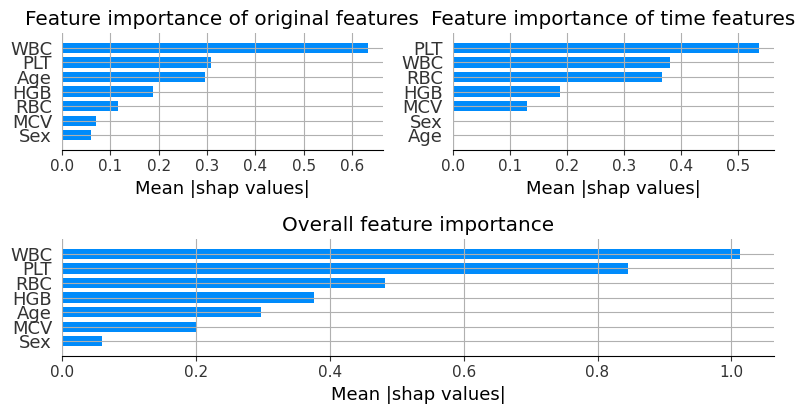

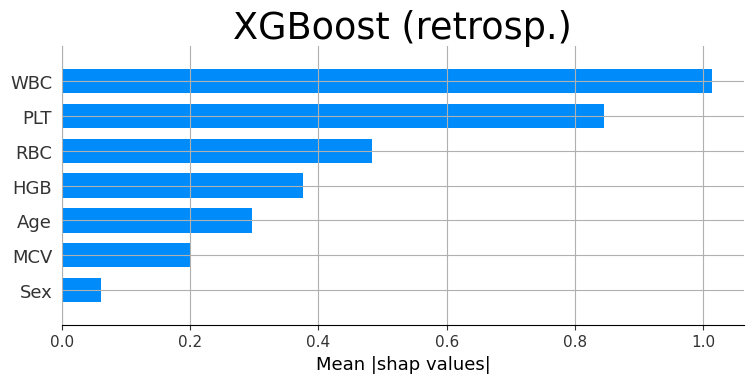

In [30]:
explainer = shap.TreeExplainer(retrospective_model_xgb)
X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
features_test = torch.cat(get_features(framework_rev, X_test, edge_index_test), dim = 1).cpu().numpy()
retrospective_xgb_test_shap_vals = None
if os.path.exists('retrospective_xgb_test_shap_vals.npy'):
    retrospective_xgb_test_shap_vals = np.load('retrospective_xgb_test_shap_vals.npy')
else:
    retrospective_xgb_test_shap_vals = explainer.shap_values(features_test)
    np.save('retrospective_xgb_test_shap_vals.npy', retrospective_xgb_test_shap_vals)
print_and_export_shap_overview(retrospective_xgb_test_shap_vals, "retrospective_xgb", "XGBoost (retrosp.)")

## Decision tree

### Prospective model

In [50]:
prospective_model_dt, framework_dir = fit_prospective_model(DecisionTreeClassifier(**{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 9, 'min_samples_leaf': 0.017380114884534385, 'min_samples_split': 0.04015651476483255, 'random_state': 42, 'splitter': 'best'}))
eval_dict = evaluate_prospective_model(prospective_model_dt, framework_dir)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_prospective_threshold(prospective_model_dt, framework_dir)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_propsective_sensistivity_at_specifity(prospective_model_dt, framework_dir)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('prospective_decision_tree.joblib'):
    dump(prospective_model_dt, 'prospective_decision_tree.joblib')

,train_comp,train,val,test,gw
auroc,0.871,0.873,0.865,0.850,0.792
auprc,0.128,0.129,0.125,0.131,0.107


Best threshold is 0.0018
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.788336,0.786489,0.795107,0.787755,0.651786


In [51]:
pred_proba_dict = get_prospective_pred_proba(prospective_model_dt, framework_dir)
prospective_pred_probas[prospective_model_dt.__class__.__name__] = pred_proba_dict["test"]

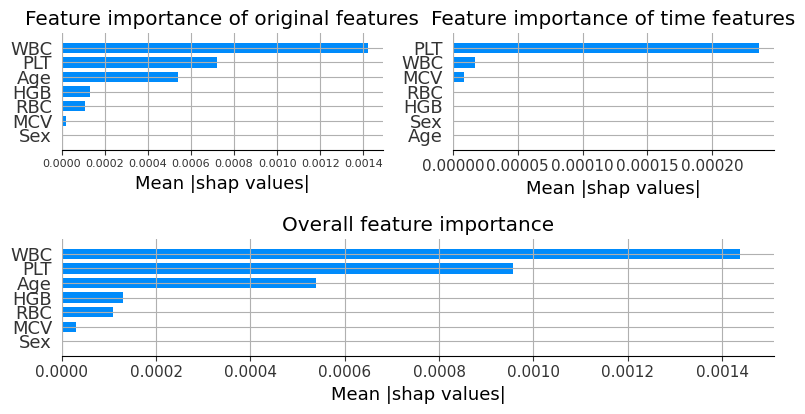

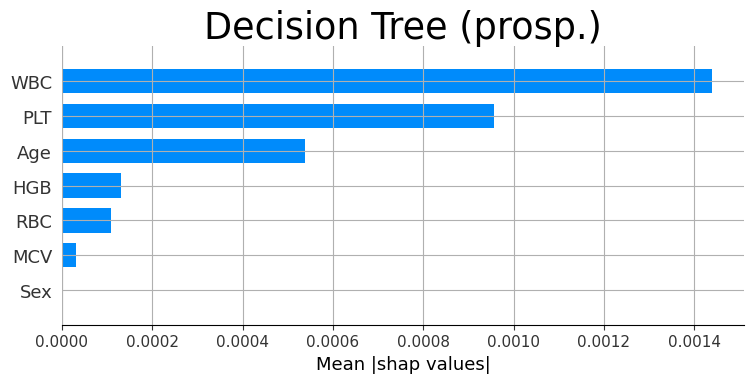

In [32]:
explainer = shap.TreeExplainer(prospective_model_dt)
X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
features_test = torch.cat(get_features(framework_dir, X_test, edge_index_test), dim = 1).cpu().numpy()
prospective_dt_test_shap_vals = None
if os.path.exists('prospective_dt_test_shap_vals.npy'):
    prospective_dt_test_shap_vals = np.load('prospective_dt_test_shap_vals.npy')
else:
    prospective_dt_test_shap_vals = explainer.shap_values(features_test)[-1]
    np.save('prospective_dt_test_shap_vals.npy', prospective_dt_test_shap_vals)
print_and_export_shap_overview(prospective_dt_test_shap_vals, "prospective_dt", "Decision Tree (prosp.)")

### Retrospective model

In [57]:
retrospective_model_dt, framework_rev = fit_retrospective_model(DecisionTreeClassifier(**{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'max_features': 12, 'min_samples_leaf': 0.01042576059847148, 'min_samples_split': 0.03151553134496568, 'random_state': 42, 'splitter': 'best'}))
eval_dict = evaluate_retrospective_model(retrospective_model_dt, framework_rev)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_restrospective_threshold(retrospective_model_dt, framework_rev)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_retrospective_sensistivity_at_specifity(retrospective_model_dt, framework_rev)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('retrospective_decision_tree.joblib'):
    dump(retrospective_model_dt, 'retrospective_decision_tree.joblib')

,train_comp,train,val,test,gw
auroc,0.942,0.942,0.940,0.927,0.925
auprc,0.209,0.210,0.207,0.197,0.175


Best threshold is 0.4511
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.933814,0.934112,0.932722,0.902041,0.917411


In [58]:
pred_proba_dict = get_retrospective_pred_proba(retrospective_model_dt, framework_rev)
retrospective_pred_probas[retrospective_model_dt.__class__.__name__] = pred_proba_dict["test"]

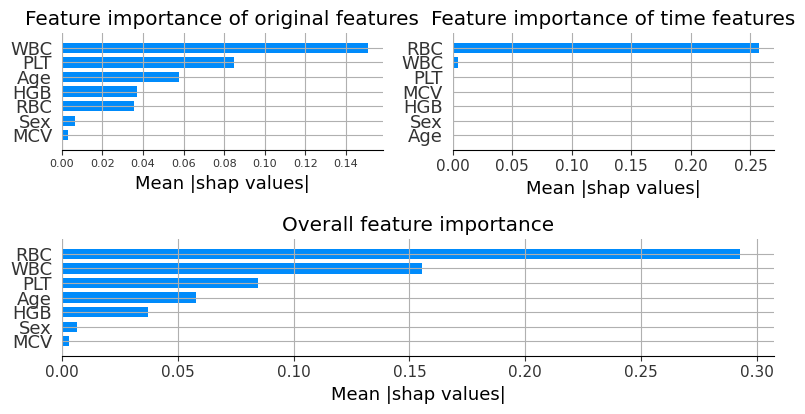

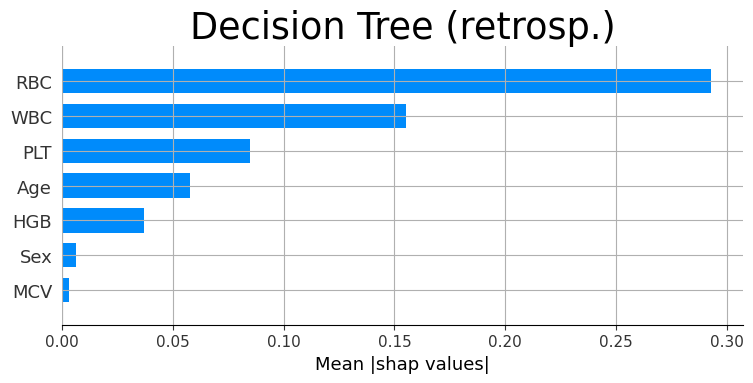

In [34]:
explainer = shap.TreeExplainer(retrospective_model_dt)
X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
features_test = torch.cat(get_features(framework_rev, X_test, edge_index_test), dim = 1).cpu().numpy()
retrospective_dt_test_shap_vals = None
if os.path.exists('retrospective_dt_test_shap_vals.npy'):
    retrospective_dt_test_shap_vals = np.load('retrospective_dt_test_shap_vals.npy')
else:
    retrospective_dt_test_shap_vals = explainer.shap_values(features_test)[-1]
    np.save('retrospective_dt_test_shap_vals.npy', retrospective_dt_test_shap_vals)
print_and_export_shap_overview(retrospective_dt_test_shap_vals, "retrospective_dt", "Decision Tree (retrosp.)")

## Export pred proba dfs

In [61]:
prospective_pred_probas.to_csv("pred_probas_prospective.csv", index = False)
retrospective_pred_probas.to_csv("pred_probas_retrospective.csv", index = False)

## RUSBoost

### Prospective model

In [35]:
prospective_model_rus, framework_dir = fit_prospective_model(RUSBoostClassifier(**{'base_estimator': DecisionTreeClassifier(), 'learning_rate': 0.02238165023926728, 'n_estimators': 160, 'random_state': 42, 'sampling_strategy': 0.66}))
eval_dict = evaluate_prospective_model(prospective_model_rus, framework_dir)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_prospective_threshold(prospective_model_rus, framework_dir)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_propsective_sensistivity_at_specifity(prospective_model_rus, framework_dir)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('prospective_rus_boost.joblib'):
    dump(prospective_model_rus, 'prospective_rus_boost.joblib')

/home/dwalke/.local/lib/python3.10/site-packages/imblearn/ensemble/_weight_boosting.py:271: FutureWarning: `base_estimator` was renamed to `estimator` in version 0.10 and will be removed in 0.12.
  warnings.warn(


,train_comp,train,val,test,gw
auroc,0.999,0.999,0.999,0.883,0.841
auprc,0.428,0.429,0.424,0.018,0.008


Best threshold is 0.0006
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,1.0,1.0,1.0,0.804082,0.727679


In [36]:
# explainer = shap.TreeExplainer(prospective_model_rus)
# X_test, edge_index_test,y_test = edge_type_sets["dir"]["test"]
# features_test = torch.cat(get_features(framework_dir, X_test, edge_index_test), dim = 1).cpu().numpy()
# prospective_rus_test_shap_vals = None
# if os.path.exists('prospective_rus_test_shap_vals.npy'):
#     prospective_rus_test_shap_vals = np.load('prospective_rus_test_shap_vals.npy')
# else:
#     prospective_rus_test_shap_vals = explainer.shap_values(features_test)[-1]
#     np.save('prospective_rus_test_shap_vals.npy', prospective_dt_test_shap_vals)
# print_and_export_shap_overview(prospective_rus_test_shap_vals, "prospective_rus")

### Retrospective model

In [37]:
retrospective_model_rus, framework_rev = fit_retrospective_model(RUSBoostClassifier(**{'base_estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 0.024992638569644884, 'n_estimators': 260, 'random_state': 42, 'sampling_strategy': 0.5}))
eval_dict = evaluate_retrospective_model(retrospective_model_rus, framework_rev)
display(HTML(pd.DataFrame(eval_dict).to_html()))
best_threshold = get_best_restrospective_threshold(retrospective_model_rus, framework_rev)
print(f"Best threshold is {best_threshold}")
sensitivity_vals = get_retrospective_sensistivity_at_specifity(retrospective_model_rus, framework_rev)
print("Sensitivity for 80% specifity")
display(HTML(pd.DataFrame(sensitivity_vals).to_html()))
if not os.path.exists('retrospective_rus_boost.joblib'):
    dump(retrospective_model_rus, 'retrospective_rus_boost.joblib')

/home/dwalke/.local/lib/python3.10/site-packages/imblearn/ensemble/_weight_boosting.py:271: FutureWarning: `base_estimator` was renamed to `estimator` in version 0.10 and will be removed in 0.12.
  warnings.warn(


,train_comp,train,val,test,gw
auroc,0.957,0.957,0.956,0.943,0.952
auprc,0.061,0.061,0.064,0.049,0.033


Best threshold is 0.4622
Sensitivity for 80% specifity


,train_comp,train,val,test,gw
sensitivity,0.948231,0.950792,0.938838,0.922449,0.941964


In [38]:
# explainer = shap.TreeExplainer(retrospective_model_rus)
# X_test, edge_index_test,y_test = edge_type_sets["rev_dir"]["test"]
# features_test = torch.cat(get_features(framework_rev, X_test, edge_index_test), dim = 1).cpu().numpy()
# retrospective_rus_test_shap_vals = None
# if os.path.exists('retrospective_rus_test_shap_vals.npy'):
#     retrospective_rus_test_shap_vals = np.load('retrospective_rus_test_shap_vals.npy')
# else:
#     retrospective_rus_test_shap_vals = explainer.shap_values(features_test)[-1]
#     np.save('retrospective_rus_test_shap_vals.npy', retrospective_rus_test_shap_vals)
# print_and_export_shap_overview(retrospective_rus_test_shap_vals, "retrospective_rus")